In [3]:
%pip install matplotlib seaborn scipy

  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

   ---------------------------------------- 0/2 [matplotlib]

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 32] O arquivo já está sendo usado por outro processo: 'c:\\Users\\Mikaelly\\Documents\\projeto_clima_vitoria\\.venv\\Lib\\site-packages\\matplotlib\\_fontconfig_pattern.py'
Check the permissions.



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

df_clima = pd.read_csv('../data/raw/inmet_vitoria_clima_consolidado_2021_2025.csv', sep=',') 
df_desmatamento = pd.read_csv('../data/raw/mapbiomas_vitoria_agregado_2021_2024.csv', sep=',')

df_clima['DATA'] = pd.to_datetime(df_clima['DATA'])
df_clima['ANO'] = df_clima['DATA'].dt.year


df_merged = pd.merge(df_clima, df_desmatamento, on='ANO', how='inner')


display(df_merged.head())

  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached numpy-2.4.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.1.1-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pandas-3.0.1-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scipy-1.17.1-cp

,DATA,CHUVA,TEMP_MAX,TEMP_MIN,TEMP_MEDIA,ANO,AREA_DESMATADA_HA
0,2021-01-01,0.0,34.4,20.9,26.519048,2021,3.779856
1,2021-01-02,0.0,33.1,21.7,26.583333,2021,3.779856
2,2021-01-03,8.2,28.6,22.7,25.095000,2021,3.779856
3,2021-01-04,1.4,29.7,22.9,24.952174,2021,3.779856
4,2021-01-05,0.0,32.8,22.9,27.558333,2021,3.779856


In [5]:
print("Colunas do Clima:", df_clima.columns.tolist())
print("\nColunas do Desmatamento:", df_desmatamento.columns.tolist())

Colunas do Clima: ['DATA', 'CHUVA', 'TEMP_MAX', 'TEMP_MIN', 'TEMP_MEDIA', 'ANO']

Colunas do Desmatamento: ['ANO', 'AREA_DESMATADA_HA']


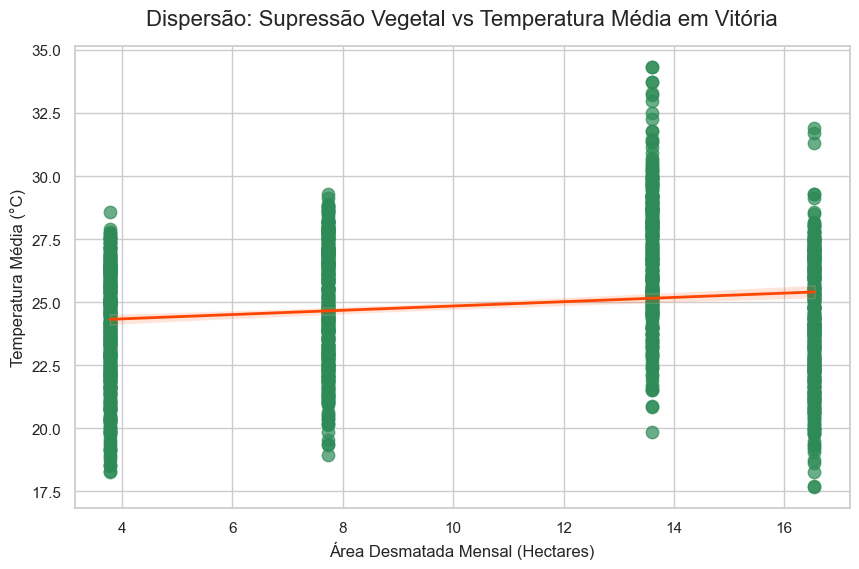

--------------------------------------------------
Coeficiente de Correlação (r): 0.157
P-value (Significância): 0.0000
--------------------------------------------------


In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_merged, 
    x='AREA_DESMATADA_HA', 
    y='TEMP_MEDIA',        
    scatter_kws={'alpha': 0.7, 'color': '#2E8B57', 's': 80},
    line_kws={'color': '#FF4500', 'linewidth': 2} 
)

plt.title('Dispersão: Supressão Vegetal vs Temperatura Média em Vitória', fontsize=16, pad=15)
plt.xlabel('Área Desmatada Mensal (Hectares)', fontsize=12)
plt.ylabel('Temperatura Média (°C)', fontsize=12)
plt.show()


df_limpo = df_merged.dropna(subset=['AREA_DESMATADA_HA', 'TEMP_MEDIA'])

correlacao, p_valor = pearsonr(df_limpo['AREA_DESMATADA_HA'], df_limpo['TEMP_MEDIA'])

print("-" * 50)
print(f"Coeficiente de Correlação (r): {correlacao:.3f}")
print(f"P-value (Significância): {p_valor:.4f}")
print("-" * 50)